# Desafío 2

Alumno: Rodrigo Mesa Marchi (a2016)

<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim



### Alumno

- Crear sus propios vectores con Gensim basado en lo visto en clase con otro dataset.
- Probar términos de interés y explicar similitudes en el espacio de embeddings (sacar conclusiones entre palabras similitudes y diferencias).
- Graficarlos.
- Obtener conclusiones.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import multiprocessing
from gensim.models import Word2Vec
from datasets import load_dataset
import tqdm
from tensorflow.keras.preprocessing.text import text_to_word_sequence
from gensim.models.callbacks import CallbackAny2Vec

from sklearn.decomposition import IncrementalPCA    
from sklearn.manifold import TSNE                   
import numpy as np        

/home/rodri/Documents/Maestria/proyectos_maestria/procesamiento_lenguaje/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-09-10 17:51:03.504632: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-10 17:51:03.579217: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-10 17:51:05.090477: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 1) Crear sus propios vectores con Gensim basado en lo visto en clase con otro dataset.

Para estas pruebas, estaremos utilizando el dataset de ag_news: https://huggingface.co/datasets/wangrongsheng/ag_news

Este dataset contiene transcripciones de articulos de noticias. Filtraremos unicamente los textos de ellas, sin preservar su etiquetado



In [2]:
dataset = load_dataset("wangrongsheng/ag_news")
train = dataset["train"]
train.set_format(type="pandas")
df_entrenamiento = train["text"].values

In [4]:
df_entrenamiento = df_entrenamiento[0:10000] # Guardamos los primero 10.000 articulos

### 1 - Preprocesamiento

In [5]:
sentence_tokens = [text_to_word_sequence(row) for row in df_entrenamiento]

In [6]:
sentence_tokens[0:2]

[['wall',
  'st',
  'bears',
  'claw',
  'back',
  'into',
  'the',
  'black',
  'reuters',
  'reuters',
  'short',
  'sellers',
  'wall',
  "street's",
  'dwindling',
  'band',
  'of',
  'ultra',
  'cynics',
  'are',
  'seeing',
  'green',
  'again'],
 ['carlyle',
  'looks',
  'toward',
  'commercial',
  'aerospace',
  'reuters',
  'reuters',
  'private',
  'investment',
  'firm',
  'carlyle',
  'group',
  'which',
  'has',
  'a',
  'reputation',
  'for',
  'making',
  'well',
  'timed',
  'and',
  'occasionally',
  'controversial',
  'plays',
  'in',
  'the',
  'defense',
  'industry',
  'has',
  'quietly',
  'placed',
  'its',
  'bets',
  'on',
  'another',
  'part',
  'of',
  'the',
  'market']]

### 2 - Crear los vectores (word2vec)

In [7]:

# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [8]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores 
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [9]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [10]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 10000


In [11]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 7747


### 3 - Entrenar embeddings

In [13]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=40,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 2122375.25
Loss after epoch 1: 1929504.75
Loss after epoch 2: 1786044.5
Loss after epoch 3: 1748913.5
Loss after epoch 4: 1669982.0
Loss after epoch 5: 1594149.0
Loss after epoch 6: 1571101.0
Loss after epoch 7: 1558003.0
Loss after epoch 8: 1544321.0
Loss after epoch 9: 1501228.0
Loss after epoch 10: 1354120.0
Loss after epoch 11: 1343110.0
Loss after epoch 12: 1331116.0
Loss after epoch 13: 1320400.0
Loss after epoch 14: 1314008.0
Loss after epoch 15: 1304144.0
Loss after epoch 16: 1292868.0
Loss after epoch 17: 1283952.0
Loss after epoch 18: 1279328.0
Loss after epoch 19: 1268460.0
Loss after epoch 20: 1263710.0
Loss after epoch 21: 1253690.0
Loss after epoch 22: 1195448.0
Loss after epoch 23: 1020412.0
Loss after epoch 24: 1008656.0
Loss after epoch 25: 1007000.0
Loss after epoch 26: 999760.0
Loss after epoch 27: 991744.0
Loss after epoch 28: 981408.0
Loss after epoch 29: 975932.0
Loss after epoch 30: 967092.0
Loss after epoch 31: 958512.0
Loss after epoch 32: 9

(12359823, 16091200)

## 2) Probar términos de interés y explicar similitudes en el espacio de embeddings (sacar conclusiones entre palabras similitudes y diferencias).

En esta sección, evaluaremos algunos terminos que pueden presentarse en las noticias, analizando palabras similares, y opuestas

In [18]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["president"], topn=10)

[('gloria', 0.534290611743927),
 ('macapagal', 0.5334092974662781),
 ('pervez', 0.5135390758514404),
 ('counterpart', 0.4799124002456665),
 ('olusegun', 0.4537712633609772),
 ('musharraf', 0.4500728249549866),
 ('kadyrov', 0.44792622327804565),
 ('akhmad', 0.4449596107006073),
 ('mikhail', 0.43670740723609924),
 ('declares', 0.42957189679145813)]

Con la palabra presidente, encontramos entre las palabras mas similares, apellidos y nombres de algunos mandatarios mundiales. A su vez, verbos usuales como **declara**

In [19]:
w2v_model.wv.most_similar(positive=["student"], topn=10)

[('graduate', 0.46849149465560913),
 ('anthony', 0.42769739031791687),
 ('duke', 0.4103064239025116),
 ('behavior', 0.38906189799308777),
 ('blackberry', 0.38885220885276794),
 ('ossetian', 0.38820987939834595),
 ('disappearing', 0.3880290389060974),
 ('williamsport', 0.387050598859787),
 ("jackson's", 0.38519662618637085),
 ('functions', 0.3799338638782501)]

Si buscamos palabras relacionadas con estudiantes, encontramos palabras como graduado, duke o anthony(universidades); pero algunas otras mas dificiles de identificar, como blackberry

In [20]:
w2v_model.wv.most_similar(negative=["student"], topn=10)

[('swing', 0.034641776233911514),
 ('need', 0.02486351877450943),
 ('tumble', 0.02339830808341503),
 ('rose', 0.0205818060785532),
 ('october', 0.01896078698337078),
 ('pushed', 0.015032125636935234),
 ('cuts', 0.014394763857126236),
 ('fall', 0.012922869995236397),
 ('tumbled', 0.011277696117758751),
 ('rather', 0.01071067713201046)]

Como palabras menos usuales, podemos encontrar palabras que no tienen relacion directa con estudiantes, como octubre o rosa.

In [23]:
w2v_model.wv.most_similar(positive=["brazil"], topn=10)

[('sao', 0.4891754686832428),
 ('paulo', 0.4395449459552765),
 ('tribe', 0.4289935827255249),
 ('piraha', 0.4174236059188843),
 ('routed', 0.4159717261791229),
 ('unbeaten', 0.38268938660621643),
 ('prince', 0.3695302903652191),
 ('stockpiles', 0.36876821517944336),
 ('semis', 0.3681793212890625),
 ('gonzalez', 0.3628334105014801)]

Si buscamos entre las noticias a Brasil, encotramos palabras como sao paulo, pirañas, etc; elementos relacionados con brasil

### 5 - Visualizar agrupación de vectores

In [24]:
def reduce_dimensions(model, num_dimensions = 2 ):
     
    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)  

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

## 3) Graficar embeddings

In [26]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
fig.show(renderer="colab") # esto para plotly en colab

Podemos encontrar que con esto las vectorizaciones de palabras arman algunos grupos marcados. Entre algunas cosas, encontramos:

1. En el centro: vemos que se organizan la mayoria de palabras, dentro de las cuales encontramos muchos conectores, o palabras usuales en el inglés (after, from, one, will).
1. Tenemos por ejemplo pequeños clusters interesantes de palabras. En la parte central a la derecha, encontramos un pequeño grupo como microsoft, security, windows:

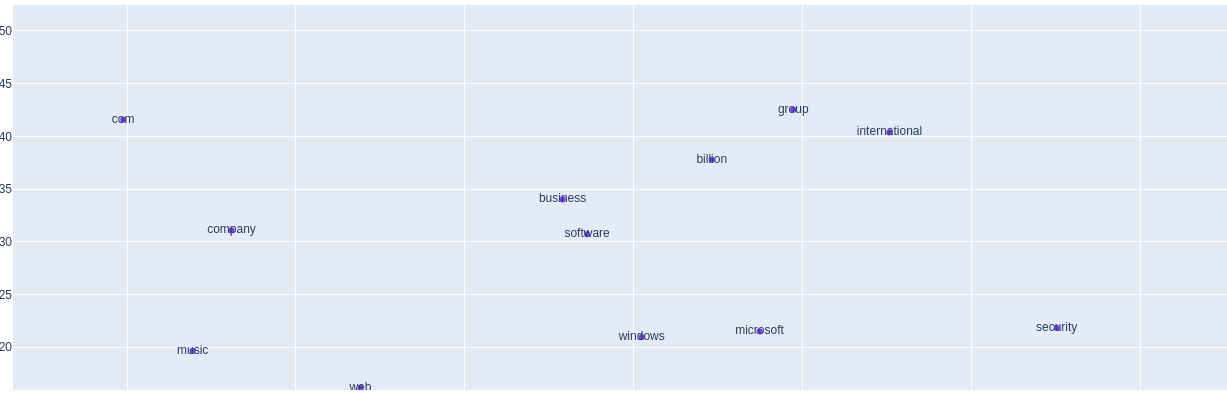
1. Otro de estos grupos puede observarse en la parte superior izquierda, donde podemos encontrar terminos financieros, como: stock, oil, percent, market.

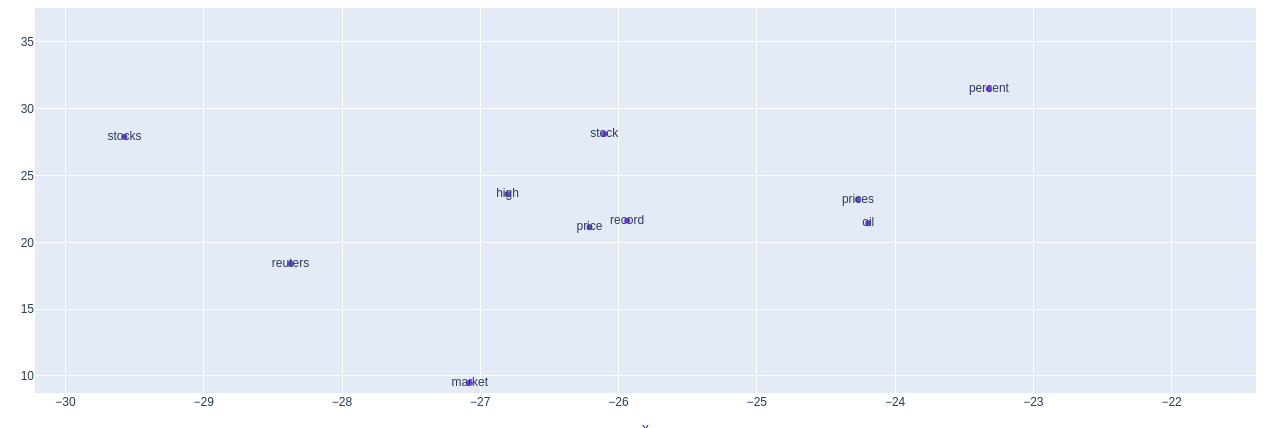

In [28]:
# Graficar los embedddings en 3D

vecs, labels = reduce_dimensions(w2v_model,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
fig.show(renderer="colab") # esto para plotly en colab

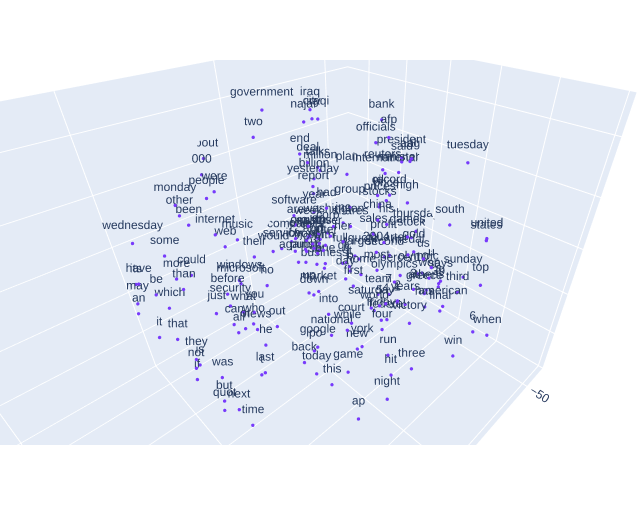

De forma similar al caso anterior, podemos encontrar como la mayoría de palabras de uso comun se encuentran al centro, sienod estas utilizadas de forma general en todo tipo de articulos. A su vez, podemos encontrar como se van formando algunos grupos de palabras, las cuales suelen asociarse mas seguido. Esto pueden ser por ejemplo nombres de paises, o palabras mas técnicas, como terminologías financieras.

## Conclusiones

Al analizar los resultados de estas pruebas, observamos cómo las tecnologías de vectorización nos permiten representar las palabras mediante estructuras numéricas. Esto facilita el análisis detallado de distintos aspectos relacionados con ellas. Gracias a estos vectores, es posible identificar las palabras más relacionadas entre sí, teniendo en cuenta el contexto específico en el que fueron utilizadas.

Estas herramientas ofrecen capacidades muy robustas, ya que permiten generar representaciones vectoriales que incorporan información contextual, posibilitando así extraer conclusiones más precisas según el ámbito de uso. En otras palabras, el significado y las relaciones entre palabras pueden variar en función de los documentos utilizados para el entrenamiento.

Por ejemplo, esta técnica puede aplicarse para identificar la evolución de narrativas en noticias, analizando cómo se relacionan las palabras entre sí al entrenar distintos datasets, segmentados por criterios como el año de publicación o el país de origen de las noticias.